### Clase 15: Visualización de datos con Seaborn

## Objetivo de la Clase
Comprender los fundamentos de Seaborn para la visualización de datos y aprender a identificar escenarios empresariales donde diferentes tipos de gráficas son útiles para tomar decisiones estratégicas.

---

## **1. Introducción a la visualización de datos en el entorno empresarial**

La visualización de datos es una herramienta clave para:
- Identificar patrones y tendencias.
- Facilitar la comunicación de hallazgos clave.
- Guiar decisiones estratégicas basadas en datos.

### **Caso inicial: Café Selecto**

Imagina que eres parte del equipo de analistas de Café Selecto, una cadena de cafeterías con presencia en varias regiones del país. En los últimos meses, las ventas han sido inconsistentes entre regiones y la dirección general ha solicitado un análisis detallado para entender los factores detrás de estas diferencias. Los datos incluyen información sobre ventas, categorías de productos, número de clientes y regiones.

Tu equipo tiene la misión de:
- Identificar patrones de consumo.
- Proponer estrategias de inventario y mercadeo basadas en datos.
- Presentar visualizaciones claras y efectivas al equipo directivo.

#### **Preguntas para reflexionar:**
- ¿Qué factores podrían estar influyendo en las diferencias de consumo entre regiones?
- ¿Qué tipo de gráficas podrían ayudarte a explorar y comunicar estos patrones?
- ¿Cómo podrías priorizar tus hallazgos para que sean útiles en la toma de decisiones?

**Diálogo:**
- ¿Cómo creen que podemos usar los datos para responder estas preguntas? Piensen en el impacto que tendría si logramos descubrir patrones claros de consumo entre las regiones. 
- ¿Qué gráficas consideran más útiles para este caso?"

---


In [2]:
# Importación de librerías y dataset
import pandas as pd

# Importar los datos
df = pd.read_csv('resources/ventas_cafe_selecto2.csv')

In [2]:
df.head()

,transaction_id,region,store_id,latitude,longitude,date,transaction_time,shift,day_of_week,season,sales,product_category,product_sku,quantity,promotion,weather,store_size,staff_count,customer_type,payment_method
0,T-1,Este,S-34,19.676637,-99.212268,12/14/2024,17:56:00,tarde,saturday,invierno,12.37,Reposteria,Croissant,1,No,lluvioso,grande,14,Nuevo,Tarjeta
1,T-2,Este,S-34,19.676637,-99.212268,4/1/2024,12:55:00,tarde,monday,primavera,78.04,Reposteria,Donut,5,No,lluvioso,grande,14,Nuevo,Tarjeta
2,T-3,Este,S-34,19.676637,-99.212268,1/1/2024,15:01:00,tarde,monday,invierno,46.34,Snacks Salados,Pretzels,2,No,frio,grande,14,Nuevo,Tarjeta
3,T-4,Norte,S-5,25.312026,-100.641144,3/6/2024,16:10:00,tarde,wednesday,primavera,57.16,Tes,Te Negro,4,No,lluvioso,grande,14,Nuevo,Digital
4,T-5,Norte,S-5,25.312026,-100.641144,12/9/2024,15:57:00,tarde,monday,invierno,10.88,Cafes,Latte,1,No,lluvioso,grande,14,Nuevo,Digital


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    5000 non-null   object 
 1   region            5000 non-null   object 
 2   store_id          5000 non-null   object 
 3   latitude          5000 non-null   float64
 4   longitude         5000 non-null   float64
 5   date              5000 non-null   object 
 6   transaction_time  5000 non-null   object 
 7   shift             5000 non-null   object 
 8   day_of_week       5000 non-null   object 
 9   season            5000 non-null   object 
 10  sales             5000 non-null   float64
 11  product_category  5000 non-null   object 
 12  product_sku       5000 non-null   object 
 13  quantity          5000 non-null   int64  
 14  promotion         5000 non-null   object 
 15  weather           5000 non-null   object 
 16  store_size        5000 non-null   object 



## **2. Introducción a Seaborn**

- **Ventajas:**
  - Simplifica la creación de gráficas estéticamente agradables.
  - Ofrece herramientas para analizar relaciones y distribuciones.
- **Relación con Pandas:** Seaborn trabaja directamente con DataFrames.
- **Tipos de gráficas comunes en Seaborn:**
  - Distribuciones: `histplot`, `kdeplot`.
  - Relaciones: `scatterplot`, `lineplot`.
  - Comparaciones categóricas: `barplot`, `boxplot`, `violinplot`.
  - Matrices: `heatmap`.

### **Actividad guiada (10 minutos):**

#### Introducción:
Ustedes son los analistas encargados de preparar un reporte para el equipo directivo. Cada tipo de gráfica tiene un propósito específico.

1. **Discusión en grupo (5 minutos):**
Queremos analizar cómo varían las ventas por región. 
- ¿Qué gráficas podríamos usar y por qué? 
- ¿Cómo podríamos combinar varias gráficas para presentar una narrativa clara?

2. **Lluvia de ideas (5 minutos):**
Ahora, imaginemos que estamos frente al equipo directivo. Ellos no tienen un trasfondo técnico. 
- ¿Cómo presentaríamos nuestras visualizaciones para que sean claras y persuasivas?
    - ¿Como mostrarían tendencias generales?
    - ¿Como mostrarían relaciones entre variables clave?
    - ¿Como compararían el desempeño entre productos?

---

## **3. Escenarios para el uso de diferentes tipos de gráficas** (20 minutos)

### **Gráficos de distribución**
- **Escenario:** Analizar la distribución de las ventas por región.
- **Gráficas recomendadas:**
  - `histplot`: Ideal para distribuciones generales.
  
![Ejemplo de histplot](https://seaborn.pydata.org/_images/histogram_stacked.png)
  - `kdeplot`: útil para analizar la densidad de los datos.
  
![Ejemplo de kdeplot](https://seaborn.pydata.org/_images/joint_kde.png)

### **Gráficos de relación**
- **Escenario:** Explorar la correlación entre ticket promedio y cantidad de clientes.
- **Gráficas recomendadas:**
  - `scatterplot`: Relación puntual.

![Ejemplo de scatterplot](https://seaborn.pydata.org/_images/different_scatter_variables.png)
  - `lineplot`: Tendencias a lo largo del tiempo.

![Ejemplo de lineplot](https://seaborn.pydata.org/_images/wide_data_lineplot.png)

### **Gráficos categóricos**
- **Escenario:** Comparar ventas promedio por tipo de producto.
- **Gráficas recomendadas:**
  - `barplot`: Comparaciones entre medias.

![Ejemplo barplot](https://seaborn.pydata.org/_images/grouped_barplot.png)
  - `boxplot`: Análisis de la variabilidad dentro de cada categoría.

![Ejemplo boxplot](https://seaborn.pydata.org/_images/grouped_boxplot.png)
  - `violinplot`: Densidad de los datos para cada categoría.

![Ejemplo boxplot](https://seaborn.pydata.org/_images/wide_form_violinplot.png)

### **Heatmaps**
- **Escenario:** Visualizar correlaciones entre variables financieras.
- **Gráfica recomendada:**
  - `heatmap`: útil para matrices de correlación.
  
![Ejemplo heatmap](https://seaborn.pydata.org/_images/many_pairwise_correlations.png)

---


## **4. Ejemplo práctico: Analizando datos de ventas**

Este ejemplo práctico tiene como objetivo desarrollar las habilidades necesarias para analizar patrones de consumo, proponer estrategias de inventario y mercadeo, y presentar hallazgos al equipo directivo mediante visualizaciones claras.

Objetivos específicos:

- Identificar patrones clave de consumo por región, categoría y tiempo.
- Evaluar relaciones y tendencias temporales en las ventas.
- Utilizar diferentes tipos de gráficas para responder preguntas empresariales.

### **Pasos del ejercicio (45 minutos):**

#### **Parte 1: Exploración inicial y limpieza de datos (10 minutos)**
- Comienza con una exploración básica para comprender el conjunto de datos y preparar las columnas necesarias para el análisis.

In [ ]:
# Importación de librerías y dataset
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Importar los datos
df.head()

,transaction_id,region,store_id,latitude,longitude,date,transaction_time,shift,day_of_week,season,sales,product_category,product_sku,quantity,promotion,weather,store_size,staff_count,customer_type,payment_method
0,T-1,Este,S-34,19.676637,-99.212268,12/14/2024,17:56:00,tarde,saturday,invierno,12.37,Reposteria,Croissant,1,No,lluvioso,grande,14,Nuevo,Tarjeta
1,T-2,Este,S-34,19.676637,-99.212268,4/1/2024,12:55:00,tarde,monday,primavera,78.04,Reposteria,Donut,5,No,lluvioso,grande,14,Nuevo,Tarjeta
2,T-3,Este,S-34,19.676637,-99.212268,1/1/2024,15:01:00,tarde,monday,invierno,46.34,Snacks Salados,Pretzels,2,No,frio,grande,14,Nuevo,Tarjeta
3,T-4,Norte,S-5,25.312026,-100.641144,3/6/2024,16:10:00,tarde,wednesday,primavera,57.16,Tes,Te Negro,4,No,lluvioso,grande,14,Nuevo,Digital
4,T-5,Norte,S-5,25.312026,-100.641144,12/9/2024,15:57:00,tarde,monday,invierno,10.88,Cafes,Latte,1,No,lluvioso,grande,14,Nuevo,Digital


In [12]:
# Convertir la columna 'date' a formato datetime
df['date'] = pd.to_datetime(df['date'])

# Validar datos nulos
print(df.isnull().sum())

transaction_id      0
region              0
store_id            0
latitude            0
longitude           0
date                0
transaction_time    0
shift               0
day_of_week         0
season              0
sales               0
product_category    0
product_sku         0
quantity            0
promotion           0
weather             0
store_size          0
staff_count         0
customer_type       0
payment_method      0
dtype: int64


#### **Parte 2: Distribución de ventas por región (10 minutos)**

Visualiza cómo se distribuyen las ventas entre regiones y analiza las diferencias.
##### **Paso 2.1: Histogramas y densidad**

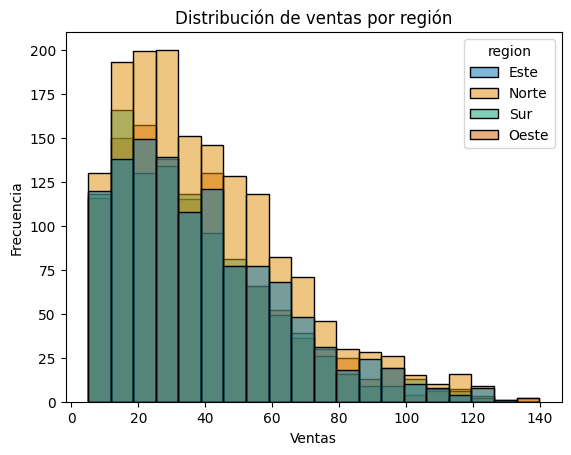

In [23]:
# Histograma para analizar la frecuencia de ventas por ticket y región
sales_per_ticket = df.groupby(['transaction_id', 'region'])['sales'].sum().reset_index()
sns.histplot(data=df, 
             x='sales', 
             hue='region', 
             bins=20, # ¿Que pasa si le movemos?
             palette='colorblind')
plt.title('Distribución de ventas por región')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.show()

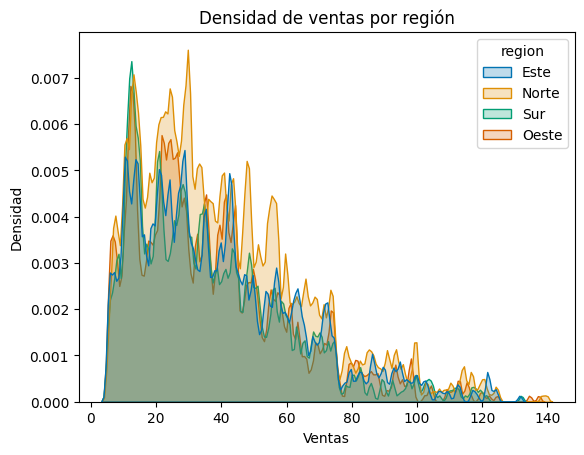

In [24]:
# Gráfico KDE para analizar densidad de ventas
sns.kdeplot(data=df, 
            x='sales', 
            hue='region', 
            fill=True, # ¿Que pasa si le movemos?
            bw_adjust=0.1,  # ¿Que pasa si le movemos?
            palette='colorblind')
plt.title('Densidad de ventas por región')
plt.xlabel('Ventas')
plt.ylabel('Densidad')
plt.show()

Reflexión:
- ¿Qué visualización proporciona una mejor perspectiva para evaluar la distribución?

##### **Paso 2.2: Ventas totales por región**

C:\Users\admin\AppData\Local\Temp\ipykernel_1820\3417756225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="region", y="sales", estimator=sum, errorbar=None, palette='muted')


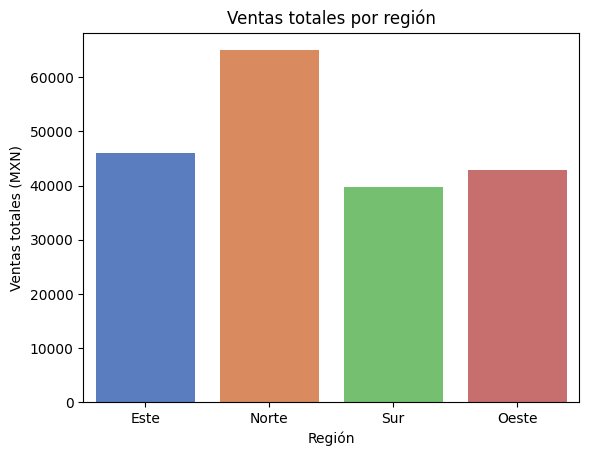

In [25]:
# Gráfica de barras: Ventas totales anuales por región
sns.barplot(data=df, x="region", y="sales", estimator=sum, errorbar=None, palette='muted')
plt.title("Ventas totales por región")
plt.xlabel("Región")
plt.ylabel("Ventas totales (MXN)")
plt.show()

Reflexión:
- ¿Qué región tiene el mejor desempeño?
- ¿Qué factores podrían explicar las diferencias?

#### **Parte 3: Relaciones y análisis temporal (10 minutos)**
##### **Paso 3.1: Relación entre cantidad de productos y ventas**

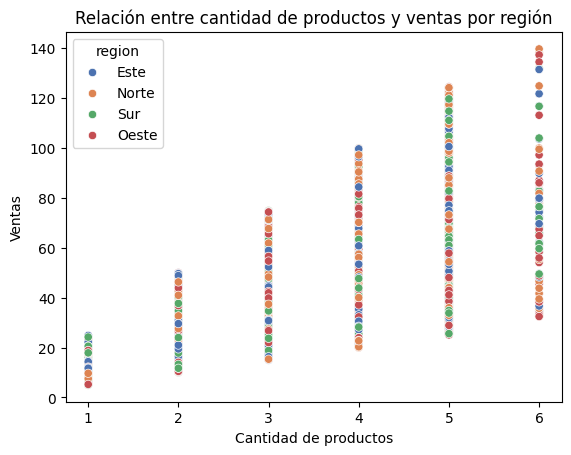

In [ ]:
# Relación entre cantidad de productos vendidos y ventas por tickettransaccion
sns.scatterplot(data=df, x='quantity', y='sales', hue='region', palette='deep')
plt.title('Relación entre cantidad de productos y ventas por región')
plt.xlabel('Cantidad de productos')
plt.ylabel('Ventas')
plt.show()

##### **Paso 3.2: Tendencias temporales**

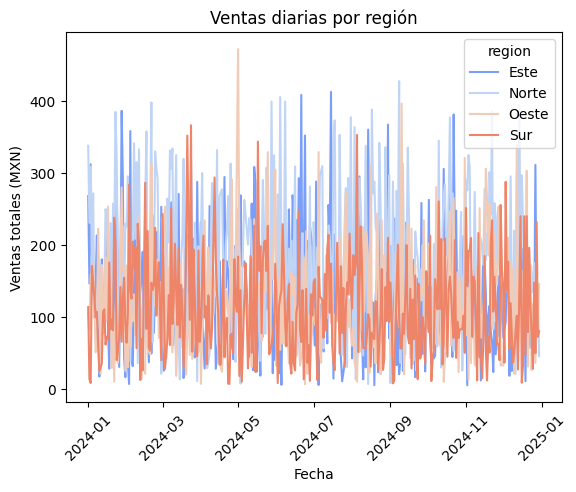

In [ ]:
# Ventas diarias por región
daily_sales = df.groupby(['date', 'region'])['sales'].sum().reset_index()
sns.lineplot(data=daily_sales, x='date', y='sales', hue='region', palette='coolwarm')
plt.title('Ventas diarias por región')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales (MXN)')
plt.xticks(rotation=45)
plt.show()

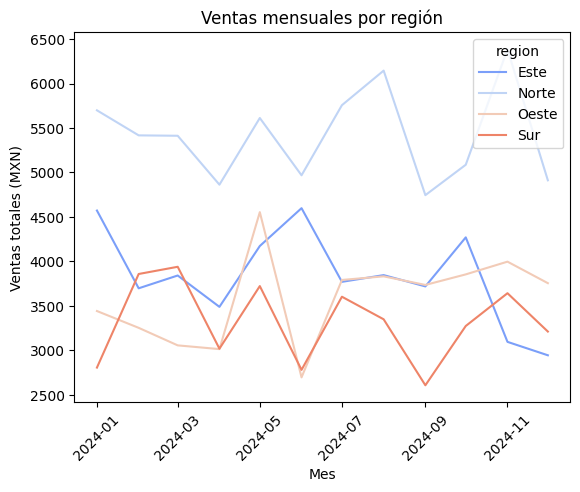

In [32]:
# Ventas mensuales por región
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()
monthly_sales = df.groupby(['month', 'region'])['sales'].sum().reset_index()
sns.lineplot(data=monthly_sales, x='month', y='sales', hue='region', palette='coolwarm')
plt.title('Ventas mensuales por región')
plt.xlabel('Mes')
plt.ylabel('Ventas totales (MXN)')
plt.xticks(rotation=45)
plt.show()

Reflexión:
- ¿Qué visualización proporciona una mejor perspectiva para evaluar tendencias?
- ¿Cómo varían las ventas según la región?

#### **Parte 4: Comparaciones categóricas (10 minutos)**

##### **Paso 4.1: Preferencias de productos por región**

In [33]:
category_quantity = df.groupby(['region', 'product_category']).agg({'quantity': 'sum'}).reset_index()
category_quantity

,region,product_category,quantity
0,Este,Cafes,1492
1,Este,Reposteria,1001
2,Este,Snacks Salados,360
3,Este,Tes,729
4,Norte,Cafes,2428
5,Norte,Reposteria,996
6,Norte,Snacks Salados,1065
7,Norte,Tes,489
8,Oeste,Cafes,1646
9,Oeste,Reposteria,1148


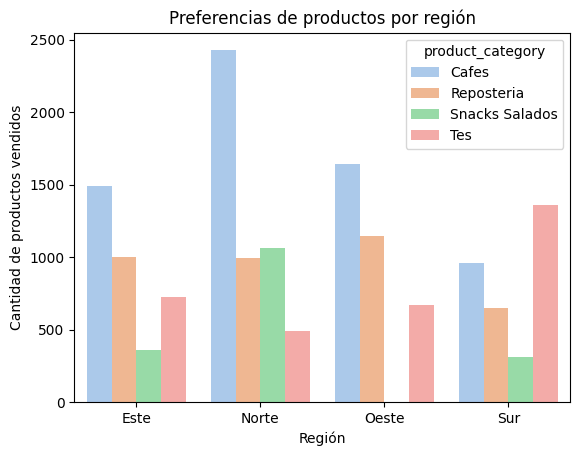

In [34]:
# Preferencias de productos: cantidad vendida por categoría y región
sns.barplot(data=category_quantity, x='region', y='quantity', hue='product_category', palette='pastel')
plt.title("Preferencias de productos por región")
plt.xlabel("Región")
plt.ylabel("Cantidad de productos vendidos")
plt.show()


##### **Paso 4.2: Variabilidad en ventas por categoría**

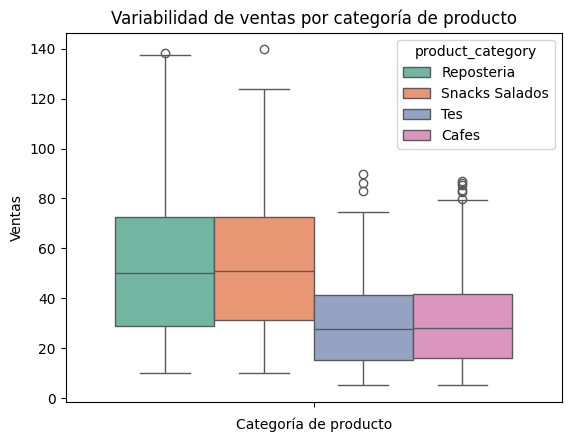

In [38]:
# Variabilidad en ventas: Boxplot
sns.boxplot(data=df, hue='product_category', y='sales', palette='Set2')
plt.title('Variabilidad de ventas por categoría de producto')
plt.xlabel('Categoría de producto')
plt.ylabel('Ventas')
plt.show()

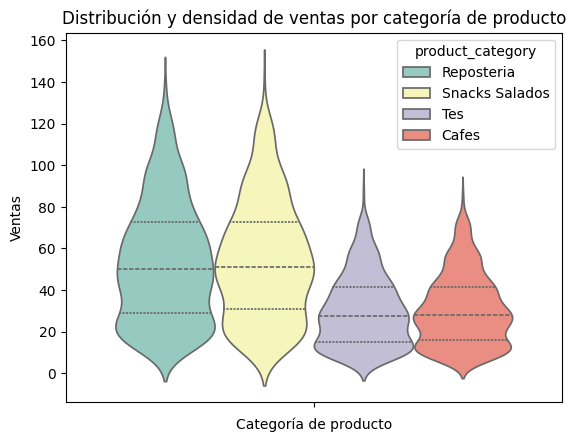

In [37]:
# Distribución y densidad: Violinplot
sns.violinplot(data=df, hue='product_category', y='sales', inner='quartile', palette='Set3')
plt.title('Distribución y densidad de ventas por categoría de producto')
plt.xlabel('Categoría de producto')
plt.ylabel('Ventas')
plt.show()

Reflexión:
- ¿Cuál de estas visualizaciones es más intuitiva para identificar patrones en las ventas?

#### **Parte 5: Matriz de correlaciones (5 minutos)**

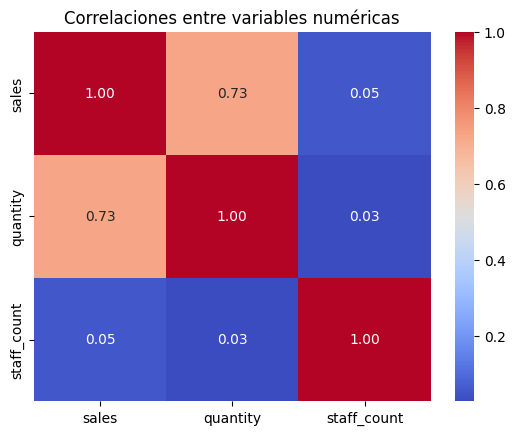

In [39]:
# Matriz de correlaciones entre variables numéricas
numerical_columns = ['sales', 'quantity', 'staff_count']
correlation_matrix = df[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlaciones entre variables numéricas')
plt.show()

Reflexión:
- ¿Qué relaciones clave se observan en las correlaciones?

---

## **5. Conclusión y reporte de laboratorio**

### 5.1 Conclusión
- Cada tipo de gráfica tiene un propósito específico en el análisis empresarial.
- Usar la gráfica correcta facilita la toma de decisiones basada en datos.
- Visualizar correctamente los datos es esencial para identificar patrones que no serían evidentes de otra forma.

### 5.1 Reporte de laboratorio
- Dado el set de datos investiga como puedes graficar la ubicación de las tiendas en un mapa usando las columnas longitud y latitud.
- Investiga como plasmar la densidad de sales que hay por zona geográfica.
- 
- Añade los comentarios y recomendaciones que le darías al CEO de Cafe Selecto de lo visto en clase y lo que observaste en las gráficas nuevas.

---

## **Reporte de Laboratorio**

### **1. Entregar el código hecho en clase**
- El código debe correr 
- Es individual

### **2. Zona Geografica**
- Dado el set de datos investiga como puedes graficar la ubicación de las tiendas en un mapa usando las columnas longitud y latitud.
- Investiga como plasmar la densidad de sales que hay por zona geográfica.
- Realiza el código correspondiente.

### **3. Explicaciones**
- Al final incluye en *Markdown*
- Recomendaciones que le darías al CEO de Cafe Selecto de lo visto en clase y lo que observaste en las gráficas nuevas.


In [4]:
df

,transaction_id,region,store_id,latitude,longitude,date,transaction_time,shift,day_of_week,season,sales,product_category,product_sku,quantity,promotion,weather,store_size,staff_count,customer_type,payment_method
0,T-1,Este,S-34,19.676637,-99.212268,12/14/2024,17:56:00,tarde,saturday,invierno,12.37,Reposteria,Croissant,1,No,lluvioso,grande,14,Nuevo,Tarjeta
1,T-2,Este,S-34,19.676637,-99.212268,4/1/2024,12:55:00,tarde,monday,primavera,78.04,Reposteria,Donut,5,No,lluvioso,grande,14,Nuevo,Tarjeta
2,T-3,Este,S-34,19.676637,-99.212268,1/1/2024,15:01:00,tarde,monday,invierno,46.34,Snacks Salados,Pretzels,2,No,frio,grande,14,Nuevo,Tarjeta
3,T-4,Norte,S-5,25.312026,-100.641144,3/6/2024,16:10:00,tarde,wednesday,primavera,57.16,Tes,Te Negro,4,No,lluvioso,grande,14,Nuevo,Digital
4,T-5,Norte,S-5,25.312026,-100.641144,12/9/2024,15:57:00,tarde,monday,invierno,10.88,Cafes,Latte,1,No,lluvioso,grande,14,Nuevo,Digital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,T-4996,Sur,S-20,18.051382,-92.783843,10/29/2024,9:47:00,maÃ±ana,tuesday,otoÃ±o,43.87,Tes,Te Verde,4,No,soleado,pequeña,7,Nuevo,Tarjeta
4996,T-4997,Sur,S-20,18.051382,-92.783843,12/22/2024,17:52:00,tarde,sunday,invierno,24.01,Tes,Te Verde,2,No,frio,pequeña,7,Nuevo,Tarjeta
4997,T-4998,Norte,S-12,25.508897,-100.543849,8/24/2024,17:29:00,tarde,saturday,verano,73.19,Cafes,Espresso,5,No,soleado,mediana,10,Nuevo,Digital
4998,T-4999,Norte,S-12,25.508897,-100.543849,1/12/2024,7:06:00,maÃ±ana,friday,invierno,22.70,Cafes,Americano,4,No,frio,mediana,10,Nuevo,Digital


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    5000 non-null   object 
 1   region            5000 non-null   object 
 2   store_id          5000 non-null   object 
 3   latitude          5000 non-null   float64
 4   longitude         5000 non-null   float64
 5   date              5000 non-null   object 
 6   transaction_time  5000 non-null   object 
 7   shift             5000 non-null   object 
 8   day_of_week       5000 non-null   object 
 9   season            5000 non-null   object 
 10  sales             5000 non-null   float64
 11  product_category  5000 non-null   object 
 12  product_sku       5000 non-null   object 
 13  quantity          5000 non-null   int64  
 14  promotion         5000 non-null   object 
 15  weather           5000 non-null   object 
 16  store_size        5000 non-null   object 


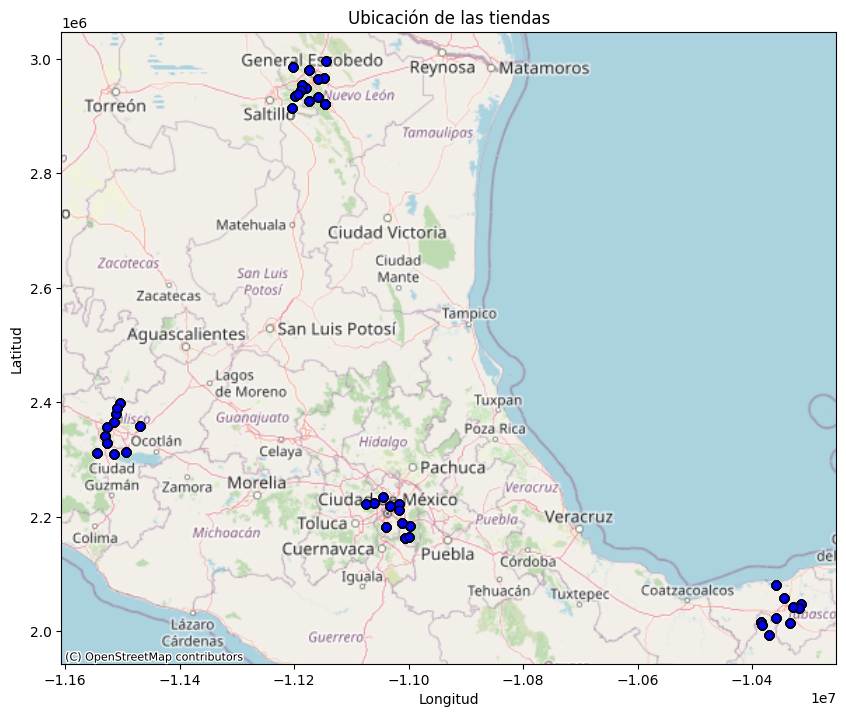

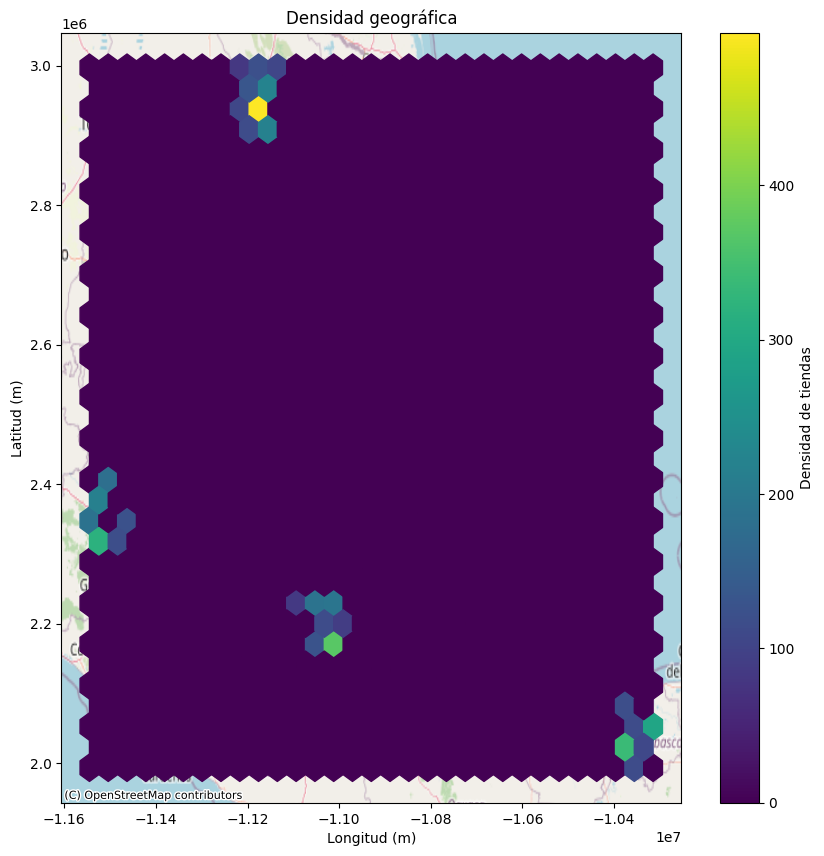

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx


# Asumir que 'df' ya está cargado

# Función para identificar columnas de latitud y longitud de forma flexible
def detect_lat_lon_columns(columns):
    lat_candidates = ['lat', 'latitud', 'latitude']
    lon_candidates = ['lon', 'long', 'longitud', 'longitude']
    lat_col = next((col for col in columns if col.lower() in lat_candidates), None)
    lon_col = next((col for col in columns if col.lower() in lon_candidates), None)
    return lat_col, lon_col

lat_col, lon_col = detect_lat_lon_columns(df.columns)
if lat_col is None or lon_col is None:
    raise ValueError("No se encontraron columnas de latitud y/o longitud en el dataset.")

# Crear geometría
geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)
gdf.crs = "EPSG:4326"  # Sistema geográfico

# Convertir a proyección Web Mercator para usar con contextily
gdf_3857 = gdf.to_crs(epsg=3857)

# --- Mapa de ubicaciones de tiendas ---
ax = gdf_3857.plot(figsize=(10, 10), alpha=0.7, edgecolor='k', marker='o', color='blue')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Ubicación de las tiendas")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

x = gdf_3857.geometry.x
y = gdf_3857.geometry.y

plt.figure(figsize=(10, 10))
if 'ventas' in df.columns:
    hb = plt.hexbin(x, y, C=gdf_3857['ventas'], gridsize=30, cmap='viridis', reduce_C_function=np.sum)
    plt.colorbar(hb, label='Suma de ventas')
else:
    hb = plt.hexbin(x, y, gridsize=30, cmap='viridis')
    plt.colorbar(hb, label='Densidad de tiendas')

plt.title("Densidad geográfica")
plt.xlabel("Longitud (m)")
plt.ylabel("Latitud (m)")
ctx.add_basemap(plt.gca(), source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()


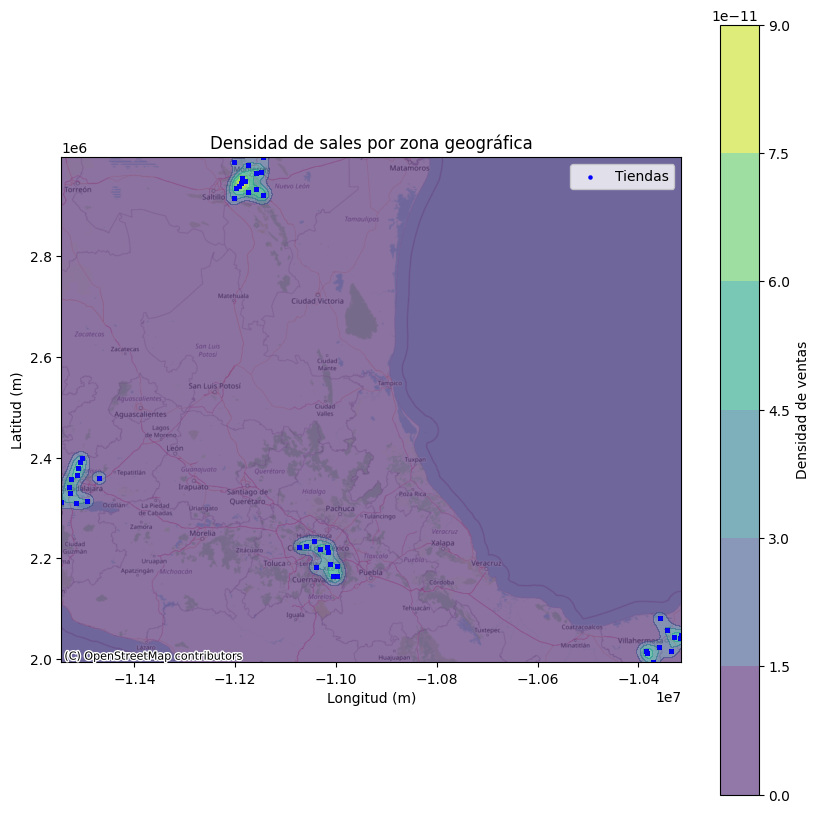

In [ ]:
from sklearn.neighbors import KernelDensity

# Supongamos que 'df' ya está cargado con las columnas de ubicación y 'ventas'

# Función para identificar columnas de latitud y longitud de forma flexible
def detect_lat_lon_columns(columns):
    lat_candidates = ['lat', 'latitud', 'latitude']
    lon_candidates = ['lon', 'long', 'longitud', 'longitude']
    lat_col = next((col for col in columns if col.lower() in lat_candidates), None)
    lon_col = next((col for col in columns if col.lower() in lon_candidates), None)
    return lat_col, lon_col

lat_col, lon_col = detect_lat_lon_columns(df.columns)
if lat_col is None or lon_col is None:
    raise ValueError("No se encontraron columnas de latitud y/o longitud en el dataset.")

# Crear geometría y GeoDataFrame
geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)
gdf.crs = "EPSG:4326"  # Sistema geográfico
gdf_3857 = gdf.to_crs(epsg=3857)  # Proyección Web Mercator

# Extraer coordenadas (en metros) y definir pesos (usando 'ventas' si existe, sino 1)
coords = np.vstack([gdf_3857.geometry.x, gdf_3857.geometry.y]).T
weights = gdf_3857['ventas'] if 'ventas' in df.columns else np.ones(len(gdf_3857))

# Definir malla (grid) para la estimación KDE
xmin, ymin, xmax, ymax = gdf_3857.total_bounds
# Generar una malla fina (ajusta la resolución con el número de puntos)
X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
grid_coords = np.vstack([X.ravel(), Y.ravel()]).T

# Ajustar el modelo KDE. El ancho de banda puede ajustarse según el caso.
bandwidth = (xmax - xmin) / 100  
kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
kde.fit(coords, sample_weight=weights)
log_density = kde.score_samples(grid_coords)
density = np.exp(log_density).reshape(X.shape)

# Graficar la densidad con contornos y superponer las ubicaciones
fig, ax = plt.subplots(figsize=(10,10))
cf = ax.contourf(X, Y, density, cmap='viridis', alpha=0.6)
gdf_3857.plot(ax=ax, markersize=5, color='blue', label='Tiendas')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Densidad de sales por zona geográfica")
plt.xlabel("Longitud (m)")
plt.ylabel("Latitud (m)")
plt.legend()
plt.colorbar(cf, label="Densidad de ventas")
plt.show()


# Recomendaciones para el CEO de Café Selecto

A partir de lo visto en clase y del análisis de las nuevas gráficas de ubicación y densidad de ventas, se proponen las siguientes recomendaciones:

- **Optimización de Ubicaciones de Tiendas**  
  - **Concentración en Áreas de Alta Densidad:** Las gráficas de localización y de densidad muestran clusters donde las ventas son significativamente mayores. Es recomendable reforzar la presencia en estas zonas con campañas de fidelización, promociones y mejoras en la experiencia de cliente.
  - **Oportunidades en Áreas No Cubiertas:** Identificar áreas con alta densidad poblacional y actividad comercial que actualmente tienen menor presencia de tiendas. Esto puede abrir oportunidades para la expansión y captación de nuevos clientes.

- **Estrategia de Marketing Local**  
  - **Campañas Personalizadas:** Utilizar la información geoespacial para diseñar campañas de marketing dirigidas a las regiones con mayor potencial de ventas.
  - **Colaboraciones Estratégicas:** Evaluar alianzas locales en zonas con alta concentración para aumentar la visibilidad y fortalecer la presencia de marca.

- **Optimización Logística y Distribución**  
  - **Rutas de Distribución Eficientes:** Con la identificación de clusters de ventas, se puede rediseñar la logística para asegurar tiempos de entrega óptimos y reducir costos.
  - **Análisis de Demanda Regional:** Utilizar los datos de densidad para predecir picos de demanda en ciertas zonas y ajustar el inventario de manera proactiva.

- **Monitoreo y Actualización de Datos**  
  - **Seguimiento Continuo:** Implementar un sistema de análisis geoespacial que permita actualizar y monitorear constantemente la densidad de ventas y el desempeño de cada tienda.
  - **Feedback y Ajustes:** Recoger datos de retroalimentación de cada zona para ajustar estrategias en función de las necesidades y comportamientos específicos de los clientes.